In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [77]:
# Load the Wine dataset

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

print("Shape:", X.shape)
print("Class counts:\n", y.value_counts().sort_index())
print("Target names:", wine.target_names)

Shape: (178, 13)
Class counts:
 target
0    59
1    71
2    48
Name: count, dtype: int64
Target names: ['class_0' 'class_1' 'class_2']


In [78]:
# Standardize the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std after scaling (should be ~1) :", np.round(X_scaled.std(axis=0)[:5], 3))

Mean after scaling (should be ~0): [-0. -0. -0. -0. -0.]
Std after scaling (should be ~1) : [1. 1. 1. 1. 1.]


In [79]:
# Apply PCA for 2D visualization

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.36198848 0.1920749 ]
Total explained variance: 0.5540633835693527


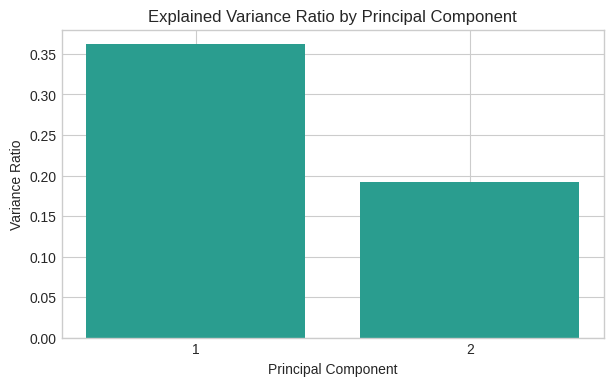

In [80]:
# Explained Variance by Principal Component

plt.figure(figsize=(7, 4))

plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    color="#2a9d8f"
)

plt.title("Explained Variance Ratio by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.xticks([1, 2])

plt.show()

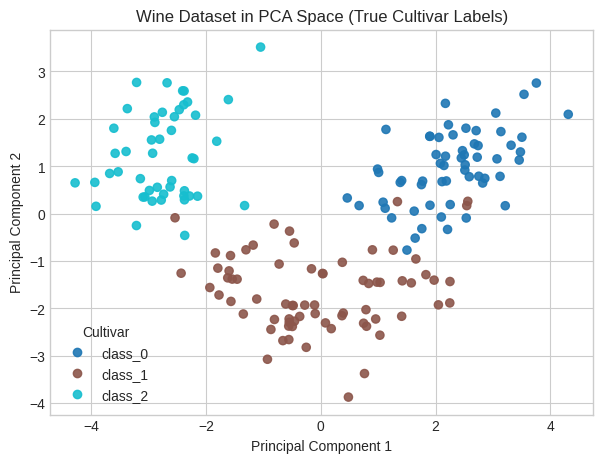

In [81]:
# PCA Projection Colored by True Wine Cultivar (reference only)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("Wine Dataset in PCA Space (True Cultivar Labels)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(wine.target_names),
    title="Cultivar"
)

plt.show()

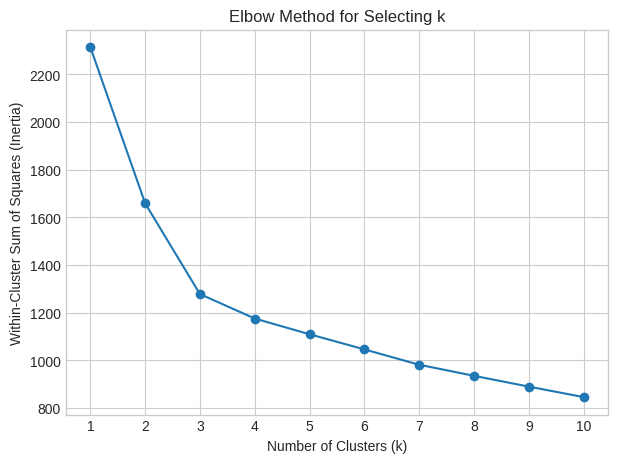

In [82]:
# Elbow Method for K-Means

from sklearn.cluster import KMeans

k_values = range(1, 11)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))

plt.plot(k_values, wcss, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Selecting k")
plt.xticks(k_values)

plt.show()

In [83]:
from sklearn.cluster import KMeans

# Initialize the model
kmeans_model = KMeans(
    n_clusters=10,       # Chosen from the elbow plot and known cultivar count
    random_state=42,
    n_init=10
)

# Fit the model
kmeans_model.fit(X_scaled)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [84]:
# Display Model Information

print("Number of Clusters :", kmeans_model.n_clusters)
print("Inertia             :", round(kmeans_model.inertia_, 2))
print("Iterations Run       :", kmeans_model.n_iter_)

Number of Clusters : 10
Inertia             : 845.9
Iterations Run       : 8


In [85]:
# Cluster Assignments

labels_kmeans = kmeans_model.labels_

kmeans_counts = pd.Series(labels_kmeans).value_counts().sort_index()
print("Cluster sizes:\n", kmeans_counts)

Cluster sizes:
 0     4
1    10
2    18
3    19
4    17
5    27
6    24
7    22
8    18
9    19
Name: count, dtype: int64


In [86]:
# Evaluate K-Means

silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)

print(f"Silhouette Score      : {silhouette_kmeans:.4f}")
print(f"Davies-Bouldin Index  : {db_kmeans:.4f}")

Silhouette Score      : 0.1436
Davies-Bouldin Index  : 1.7070


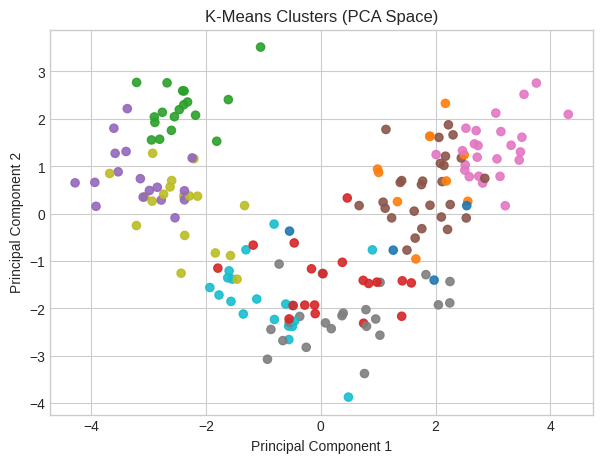

In [87]:
# Visualize K-Means Clusters in PCA Space

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("K-Means Clusters (PCA Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

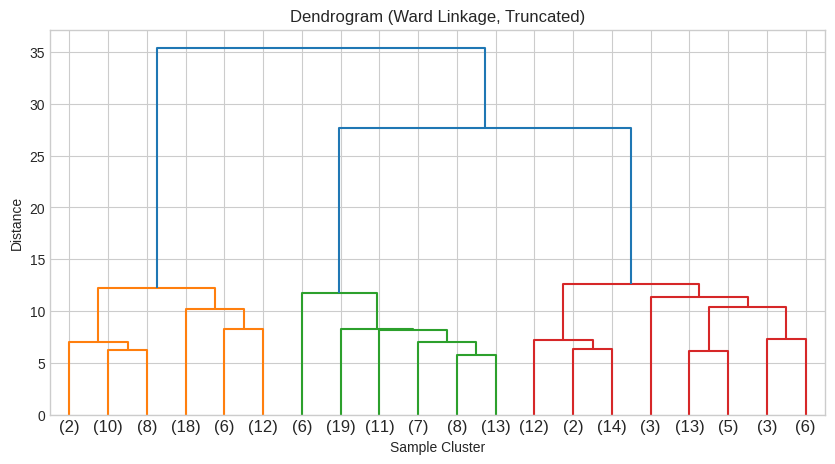

In [88]:
# Dendrogram for Hierarchical Clustering

plt.figure(figsize=(10, 5))

merge_matrix = linkage(X_scaled, method="ward")

dendrogram(merge_matrix, truncate_mode="lastp", p=20)

plt.title("Dendrogram (Ward Linkage, Truncated)")
plt.xlabel("Sample Cluster")
plt.ylabel("Distance")

plt.show()

In [89]:
# Train Agglomerative (Hierarchical) Clustering

from sklearn.cluster import AgglomerativeClustering

# Initialize the model
hier_model = AgglomerativeClustering(
    n_clusters=3,        # Chosen to match the dendrogram cut
    linkage="ward"
)

# Fit and predict in one step
labels_hier = hier_model.fit_predict(X_scaled)

print("Hierarchical Clustering model trained successfully!")

Hierarchical Clustering model trained successfully!


In [90]:
# Display Model Information

print("Number of Clusters :", hier_model.n_clusters_)
print("Linkage Method       :", hier_model.linkage)

hier_counts = pd.Series(labels_hier).value_counts().sort_index()
print("Cluster sizes:\n", hier_counts)

Number of Clusters : 3
Linkage Method       : ward
Cluster sizes:
 0    58
1    56
2    64
Name: count, dtype: int64


In [91]:
# Evaluate Hierarchical Clustering

silhouette_hier = silhouette_score(X_scaled, labels_hier)
db_hier = davies_bouldin_score(X_scaled, labels_hier)

print(f"Silhouette Score      : {silhouette_hier:.4f}")
print(f"Davies-Bouldin Index  : {db_hier:.4f}")

Silhouette Score      : 0.2774
Davies-Bouldin Index  : 1.4186


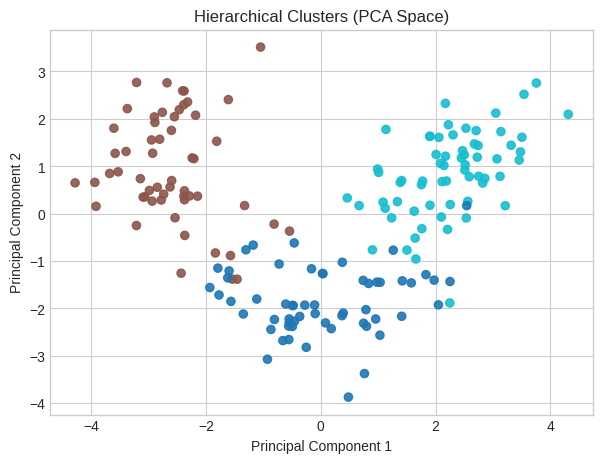

In [92]:
# Visualize Hierarchical Clusters in PCA Space

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_hier,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("Hierarchical Clusters (PCA Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

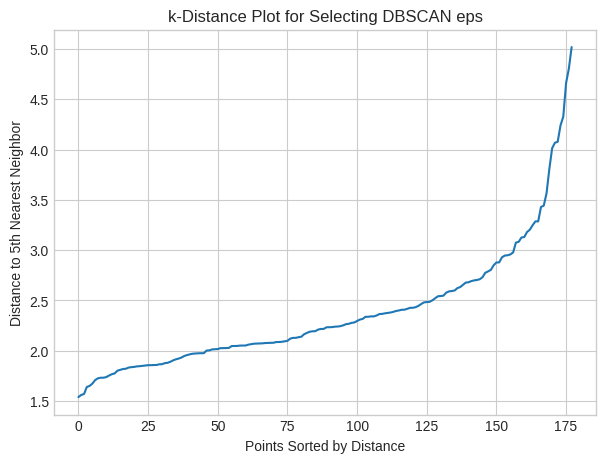

In [93]:
# k-Distance Plot for Selecting DBSCAN's eps

from sklearn.neighbors import NearestNeighbors

k = 5  # equal to min_samples used below
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)

distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(7, 5))

plt.plot(k_distances)

plt.xlabel("Points Sorted by Distance")
plt.ylabel(f"Distance to {k}th Nearest Neighbor")
plt.title("k-Distance Plot for Selecting DBSCAN eps")

plt.show()

In [94]:
# Train DBSCAN

from sklearn.cluster import DBSCAN

# Initialize the model
dbscan_model = DBSCAN(
    eps=2.2,          # Chosen from the "elbow" of the k-distance plot
    min_samples=5
)

# Fit and predict in one step
labels_dbscan = dbscan_model.fit_predict(X_scaled)

print("DBSCAN model trained successfully!")

DBSCAN model trained successfully!


In [95]:
# Display Model Information

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = int((labels_dbscan == -1).sum())

print("Epsilon (eps)        :", dbscan_model.eps)
print("Min Samples          :", dbscan_model.min_samples)
print("Clusters Found        :", n_clusters_dbscan)
print("Noise Points          :", n_noise)

Epsilon (eps)        : 2.2
Min Samples          : 5
Clusters Found        : 2
Noise Points          : 55


In [96]:
# Evaluate DBSCAN

# Exclude noise points (-1) before computing internal metrics
valid_mask = labels_dbscan != -1

if n_clusters_dbscan > 1 and valid_mask.sum() > n_clusters_dbscan:
    silhouette_dbscan = silhouette_score(X_scaled[valid_mask], labels_dbscan[valid_mask])
    db_dbscan = davies_bouldin_score(X_scaled[valid_mask], labels_dbscan[valid_mask])
else:
    silhouette_dbscan = np.nan
    db_dbscan = np.nan

print(f"Silhouette Score      : {silhouette_dbscan:.4f}")
print(f"Davies-Bouldin Index  : {db_dbscan:.4f}")

Silhouette Score      : 0.3480
Davies-Bouldin Index  : 1.1244


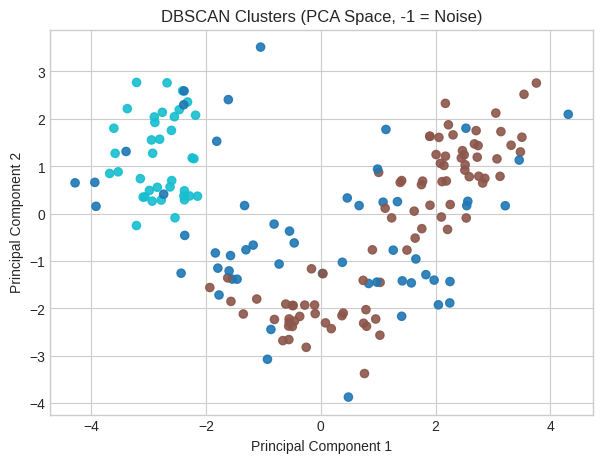

In [97]:
# Visualize DBSCAN Clusters in PCA Space

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("DBSCAN Clusters (PCA Space, -1 = Noise)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [98]:
# Compare All Models

comparison = [
    ["K-Means", kmeans_model.n_clusters, silhouette_kmeans, db_kmeans],
    ["Hierarchical", hier_model.n_clusters_, silhouette_hier, db_hier],
    ["DBSCAN", n_clusters_dbscan, silhouette_dbscan, db_dbscan],
]

comparison_df = pd.DataFrame(
    comparison,
    columns=["Algorithm", "Clusters Found", "Silhouette Score", "Davies-Bouldin Index"]
)

comparison_df = comparison_df.round(4)

comparison_df

,Algorithm,Clusters Found,Silhouette Score,Davies-Bouldin Index
0,K-Means,10,0.1436,1.7070
1,Hierarchical,3,0.2774,1.4186
2,DBSCAN,2,0.3480,1.1244


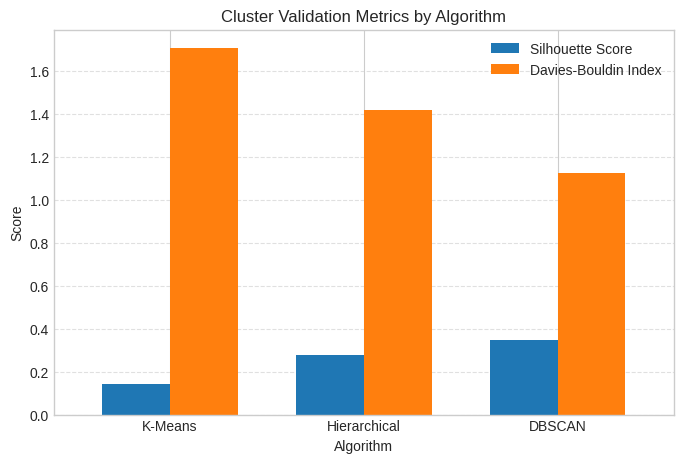

In [99]:
# Grouped Bar Chart of Cluster Validation Metrics

comparison_df.set_index("Algorithm")[
    ["Silhouette Score", "Davies-Bouldin Index"]
].plot(
    kind="bar",
    figsize=(8, 5),
    width=0.7
)

plt.title("Cluster Validation Metrics by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(loc="upper right")
plt.show()

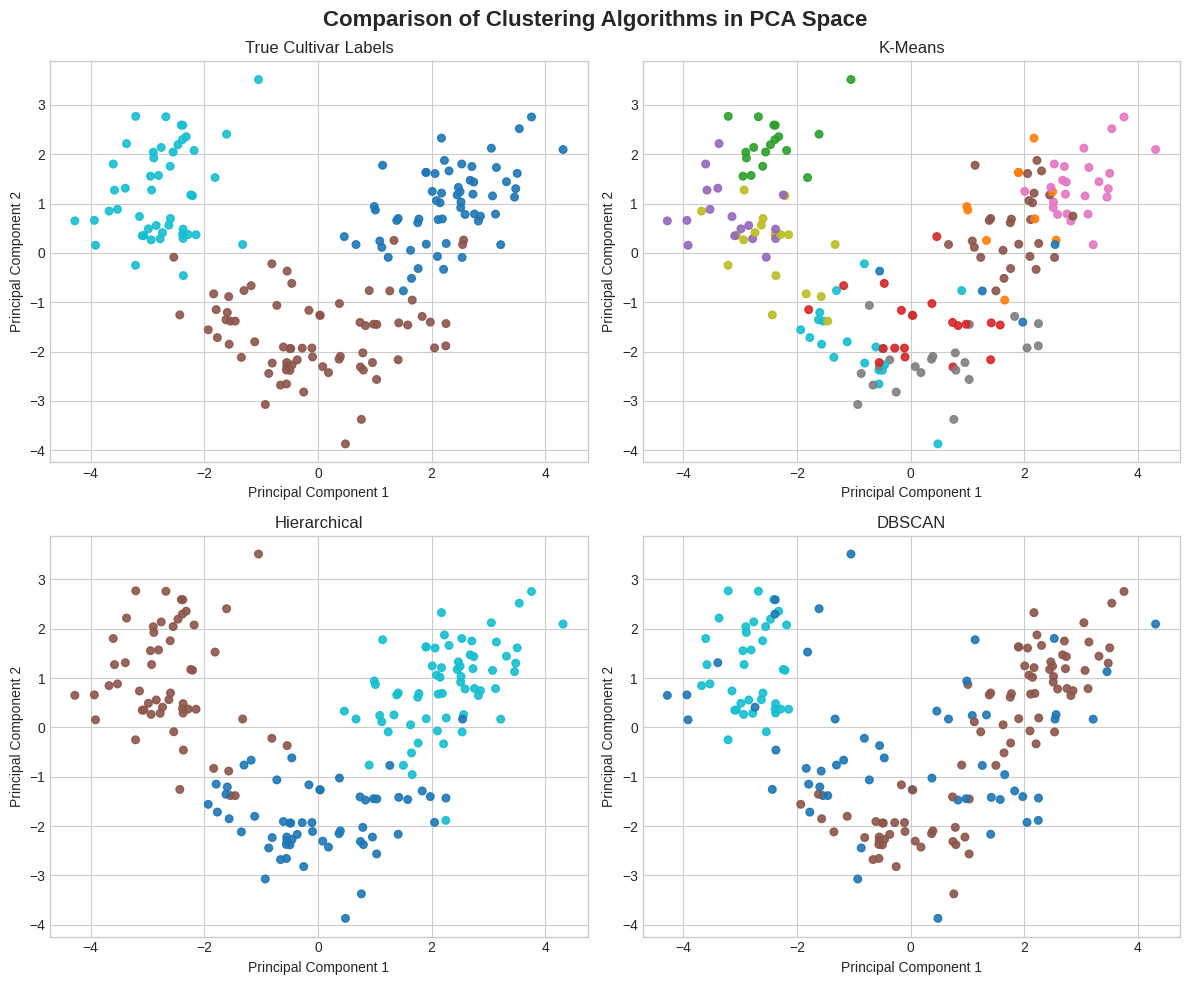

In [100]:
# Side-by-Side Cluster Comparison in PCA Space

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

panels = {
    "True Cultivar Labels": y,
    "K-Means": labels_kmeans,
    "Hierarchical": labels_hier,
    "DBSCAN": labels_dbscan,
}

for ax, (name, labels) in zip(axes, panels.items()):

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="tab10",
        s=30,
        alpha=0.9
    )

    ax.set_title(name)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

plt.suptitle(
    "Comparison of Clustering Algorithms in PCA Space",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()